# GeoSketch — density-aware sketching as a metacell baseline

> Hie et al. *Geometric sketching compactly summarizes the single-cell
> transcriptomic landscape.* **Cell Systems** 8, 483–493 (2019).
> [doi:10.1016/j.cels.2019.05.003](https://doi.org/10.1016/j.cels.2019.05.003)

**Algorithm.** GeoSketch is a **density-aware subsampling** method — it picks
`n_metacells` sketch cells that cover the manifold more evenly than uniform
random.  We then assign every non-sketch cell to its nearest sketch cell
(cosine) to produce a partition.

**Capabilities.** ``out_of_sample`` (nearest-prototype fallback).

**Strengths.** Very fast.  **Preserves rare populations** better than uniform
random because it actively oversamples low-density regions.  For
visualisation / clustering / kNN graph construction tasks this can be
sufficient.

**Weaknesses.** Each "metacell" is really just one cell — there's no
aggregation in the strict sense.  For DE / pseudobulk applications you still
need to do the local-neighbourhood aggregation yourself (or pair it with
nearest-prototype sum, as omicverse does).

## 1. Setup

In [1]:
# Standard imports + omicverse defaults.
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import omicverse as ov
import scvelo as scv      # only used for the demo dataset

ov.plot_set()

🔬 Starting plot initialization...
🧬 Detecting GPU devices…


✅ NVIDIA CUDA GPUs detected: 1
    • [CUDA 0] NVIDIA H100 80GB HBM3
      Memory: 79.1 GB | Compute: 9.0

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.2.0   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.



## 2. Load and preprocess

In [2]:
# Pancreas scRNA-seq (Bastidas-Ponce et al. 2019). Standard omicverse
# preprocess flow: qc -> preprocess -> scale -> pca -> neighbors -> umap.
adata = scv.datasets.pancreas()
adata = ov.pp.qc(adata,
                 tresh={'mito_perc': 0.20, 'nUMIs': 500, 'detected_genes': 250},
                 mt_startswith='mt-')
adata = ov.pp.preprocess(adata, mode='shiftlog|pearson', n_HVGs=2000)
adata.layers['lognorm'] = adata.X.copy()        # mcRigor reads this
adata = adata[:, adata.var.highly_variable_features]
ov.pp.scale(adata)
ov.pp.pca(adata, layer='scaled', n_pcs=30)
adata.obsm['X_pca'] = adata.obsm['scaled|original|X_pca']
ov.pp.neighbors(adata, n_neighbors=15, use_rep='X_pca')
ov.pp.umap(adata)
print('adata:', adata.shape, 'celltypes:', sorted(adata.obs['clusters'].unique()))

🖥️ Using CPU mode for QC...

📊 Step 1: Calculating QC Metrics

   ✓ Gene Family Detection:
   ┌──────────────────────────────┬────────────────────┬────────────────────┐
   │ Gene Family                  │ Genes Found        │ Detection Method   │
   ├──────────────────────────────┼────────────────────┼────────────────────┤
   │ Mitochondrial                │ 13                 │ Auto (MT-)         │
   ├──────────────────────────────┼────────────────────┼────────────────────┤
   │ Ribosomal                    │ 0 ⚠️               │ Auto (RPS/RPL)     │
   ├──────────────────────────────┼────────────────────┼────────────────────┤
   │ Hemoglobin                   │ 0 ⚠️               │ Auto (regex)       │
   └──────────────────────────────┴────────────────────┴────────────────────┘

   ✓ QC Metrics Summary:
   ┌─────────────────────────┬────────────────────┬─────────────────────────┐
   │ Metric                  │ Mean               │ Range (Min - Max)       │
   ├─────────────────────

   ✓ Final filtering: 0 cells, 12,261 genes removed

🔍 Step 4: Doublet Detection
   💡 Running pyscdblfinder (Python port of R scDblFinder)
   🔍 Running scdblfinder detection...


[ScDblFinder] wrote scDblFinder_score + scDblFinder_class — threshold=0.387
   ✓ scDblFinder completed: 66 doublets removed (1.8%)



╭─ SUMMARY: qc ──────────────────────────────────────────────────────╮
│  Duration: 17.7002s                                                │
│  Shape:    3,696 x 27,998 (Unchanged)                              │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● OBS    │ ✚ cell_complexity (float)                              │
│           │ ✚ detected_genes (int)                                 │
│           │ ✚ hb_perc (float)                                      │
│           │ ✚ mito_perc (float)                                    │
│           │ ✚ nUMIs (float)                                        │
│           │ ✚ n_counts (float)                                     │
│           │ ✚ n_genes (int)                                        │
│           │ ✚ n_genes_by_counts (int)                              │
│    

    After filtration, 15737/15737 genes are kept.
    Among 15737 genes, 15736 genes are robust.
✅ Robust gene identification completed successfully.
Begin size normalization: shiftlog and HVGs selection pearson


...


╭─ SUMMARY: scale ───────────────────────────────────────────────────╮
│  Duration: 0.6656s                                                 │
│  Shape:    3,630 x 2,000 (Unchanged)                               │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● LAYERS │ ✚ scaled (array, 3630x2000)                            │
│                                                                    │
╰────────────────────────────────────────────────────────────────────╯
computing PCA🔍
    with n_comps=30
   🖥️ Using sklearn PCA for CPU computation
   🖥️ sklearn PCA backend: CPU computation
   📊 PCA input data type: ArrayView, shape: (3630, 2000), dtype: float64


   🔧 PCA solver used: covariance_eigh
    finished✅ (1.65s)

╭─ SUMMARY: pca ─────────────────────────────────────────────────────╮
│  Duration: 1.6622s                                                 │
│  Shape:    3,630 x 2,000 (Unchanged)                               │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● UNS    │ ✚ scaled|original|cum_sum_eigenvalues                  │
│           │ ✚ scaled|original|pca_var_ratios                       │
│                                                                    │
│  ● OBSM   │ ✚ scaled|original|X_pca (array, 3630x30)               │
│                                                                    │
╰────────────────────────────────────────────────────────────────────╯
🖥️ Using Scanpy CPU to calculate neighbors...

🔍 K-Nearest Neighbors Graph Construction

   🔍 Computing connectivity matrix...
   💡 Using UMAP-style connectivity


   ✓ Graph is fully connected

✅ KNN Graph Construction Completed Successfully!
   ✓ Processed: 3,630 cells with 15 neighbors each
   ✓ Results added to AnnData object:
     • 'neighbors': Neighbors metadata (adata.uns)
     • 'distances': Distance matrix (adata.obsp)
     • 'connectivities': Connectivity matrix (adata.obsp)

╭─ SUMMARY: neighbors ───────────────────────────────────────────────╮
│  Duration: 8.7172s                                                 │
│  Shape:    3,630 x 2,000 (Unchanged)                               │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
╰────────────────────────────────────────────────────────────────────╯
🔍 [2026-05-19 17:25:29] Running UMAP in 'cpu' mode...
🖥️ Using Scanpy CPU UMAP...

🔍 UMAP Dimensionality Reduction:
   Mode: cpu
   Method: umap
   Components: 2
   Min distan


✅ UMAP Dimensionality Reduction Completed Successfully!
   ✓ Embedding shape: 3,630 cells × 2 dimensions
   ✓ Results added to AnnData object:
     • 'X_umap': UMAP coordinates (adata.obsm)
     • 'umap': UMAP parameters (adata.uns)
✅ UMAP completed successfully.

╭─ SUMMARY: umap ────────────────────────────────────────────────────╮
│  Duration: 0.8138s                                                 │
│  Shape:    3,630 x 2,000 (Unchanged)                               │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● UNS    │ ✚ umap                                                 │
│           │ └─ params: {'a': 0.5830300199950147, 'b': 1.334166993228519}│
│                                                                    │
╰────────────────────────────────────────────────────────────────────╯
adata: (3630, 2000)

## 3. Fit GeoSketch + nearest-prototype assignment

In [3]:
mc = ov.single.MetaCell(
    adata.copy(), method='geosketch', n_metacells=100,
    use_rep='X_pca', random_state=0,
).fit()
print(f'fit done: {mc.method}, runtime={mc._fit_result.runtime_s:.2f} s')

fit done: geosketch, runtime=0.25 s


## 4. AnnData schema after fit

Every backend writes the same fields into ``adata`` — that's what lets the
downstream helpers below work without branching on the backend.

In [4]:
# Inspect what the fit wrote into adata via the unified schema.
print(f'method      : {mc.method}')
print(f'capabilities: {sorted(mc.capabilities)}')
print(f'n_metacells : {np.unique(mc._fit_result.assignments).size}')
print(f'runtime     : {mc._fit_result.runtime_s:.3f} s')
print(f'uns         : {dict(mc.adata.uns["metacell"])}')

method      : geosketch
capabilities: ['out_of_sample']
n_metacells : 100
runtime     : 0.246 s
uns         : {'method': 'geosketch', 'n_metacells': 100, 'n_iter': 1, 'converged': True, 'runtime_s': 0.24586987495422363, 'random_state': 0, 'capabilities': ['out_of_sample']}


## 5. Aggregate to a metacell AnnData

`predicted(method='hard', layer='counts', summary='sum')` returns a
metacell × gene AnnData with raw count totals preserved — the format that
downstream tools (SCENIC, CellPhoneDB, pseudobulk DE) actually want.

In [5]:
ad_mc = mc.predicted(method='hard', layer='counts', summary='sum',
                     celltype_label='clusters')
print(f'metacell AnnData: {ad_mc.shape}')
print(f'mean cells/metacell: {ad_mc.obs["n_cells"].mean():.1f}')
ad_mc.obs.head()

metacell AnnData: (100, 2000)
mean cells/metacell: 36.3


,n_cells,clusters,clusters_purity
mc-0,111,Pre-endocrine,0.513514
mc-1,5,Ductal,0.800000
mc-2,26,Ductal,0.653846
mc-3,29,Ngn3 high EP,1.000000
mc-4,67,Ductal,0.985075


## 6. Benchmarking metrics (purity / separation / compactness)

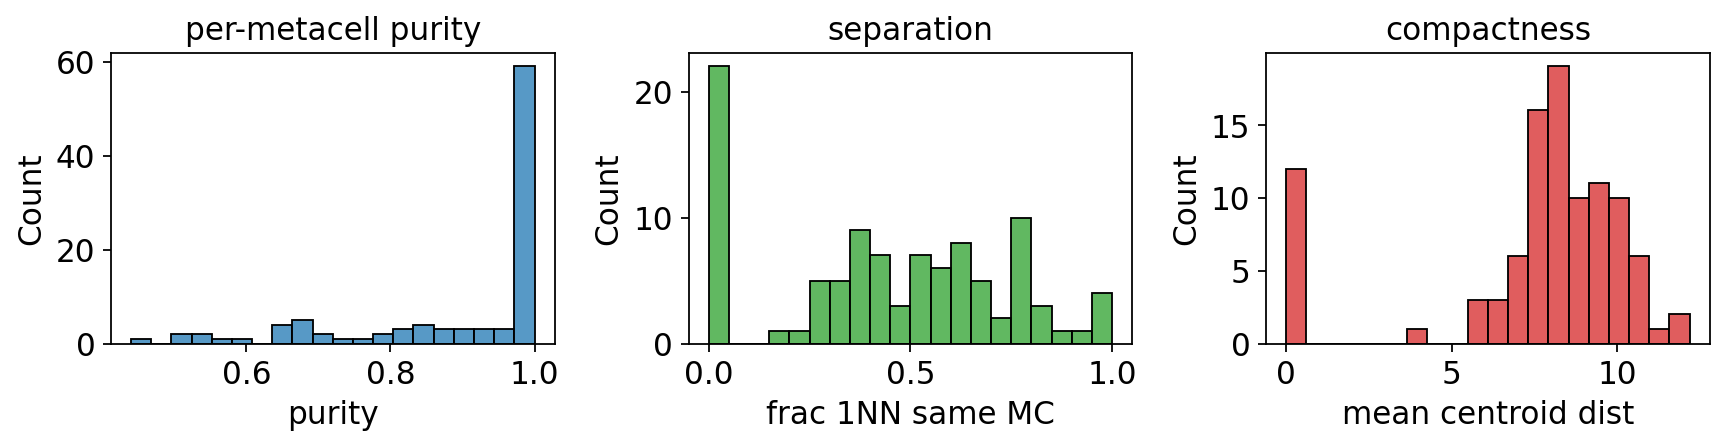

In [6]:
# Compute purity / separation / compactness AND show the 3-panel histogram
# in one call (ov.pl.metacell_metrics returns the per-metacell tables too).
purity, separation, compactness = ov.pl.metacell_metrics(
    mc, label_key='clusters', use_rep='X_pca',
)

## 7. mcRigor: statistical validation

For each metacell, mcRigor permutes the (cells × genes) submatrix in two
ways and asks: *is the observed gene–gene covariance bigger than the null
distribution at this metacell's size?*  Metacells whose `mcDiv` exceeds the
size-stratified threshold are flagged as `'dubious'`.

In [7]:
# mcRigor's double-permutation null. dubious_rate = fraction of cells in
# heterogeneous metacells; rigor_score = 1 - 0.5*(dubious_rate + zero_rate).
rep = mc.check_rigor(layer_lognorm='lognorm', n_rep=20,
                     feature_use=1000, random_state=0)
print(f'rigor_score : {rep.score:.3f}')
print(f'dubious_rate: {rep.dubious_rate:.3f}')
print(f'zero_rate   : {rep.zero_rate:.3f}')
print(f'# metacells : {rep.n_metacells}')

rigor_score : 0.461
dubious_rate: 0.786
zero_rate   : 0.293
# metacells : 100


### 7.1 Per-metacell `mcDiv` vs size

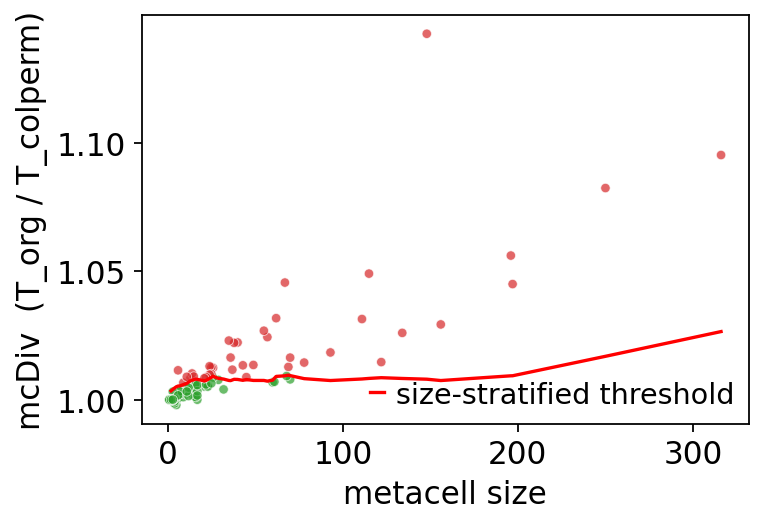

<Axes: xlabel='metacell size', ylabel='mcDiv  (T_org / T_colperm)'>

In [8]:
# mcDiv vs metacell size, overlaid with size-stratified threshold.
ov.pl.rigor_scatter(rep)

## 8. UMAP with metacell centroids

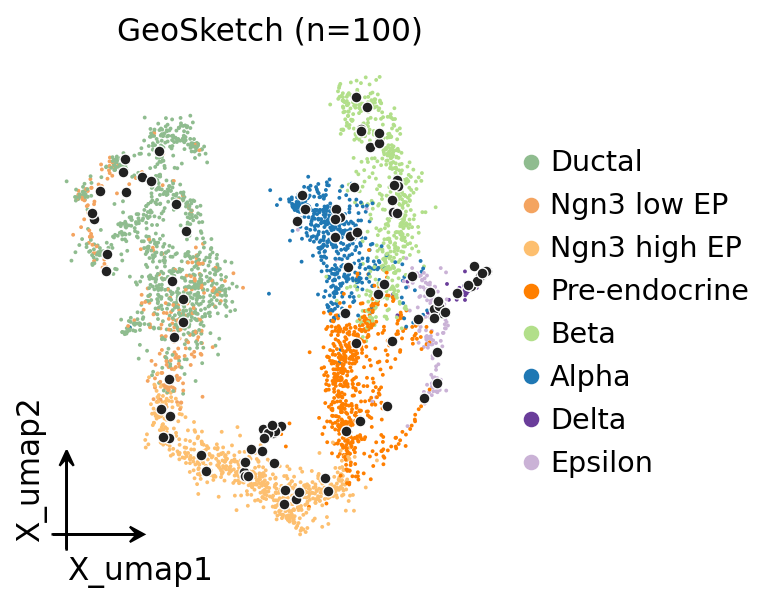

In [9]:
# UMAP coloured by celltype with metacell centroids overlaid in dark grey.
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(5, 4))
ov.pl.embedding(mc.adata, basis='X_umap', color='clusters', ax=ax, show=False,
                frameon='small', title='GeoSketch (n=100)', size=12)
labels = mc._fit_result.assignments
pts = np.array([mc.adata.obsm['X_umap'][labels == u].mean(axis=0)
                for u in np.unique(labels)])
ax.scatter(pts[:, 0], pts[:, 1], s=24, c='#222',
           edgecolors='white', linewidths=0.6, zorder=5)
plt.tight_layout(); plt.show()

## 9. Per-celltype purity boxplot

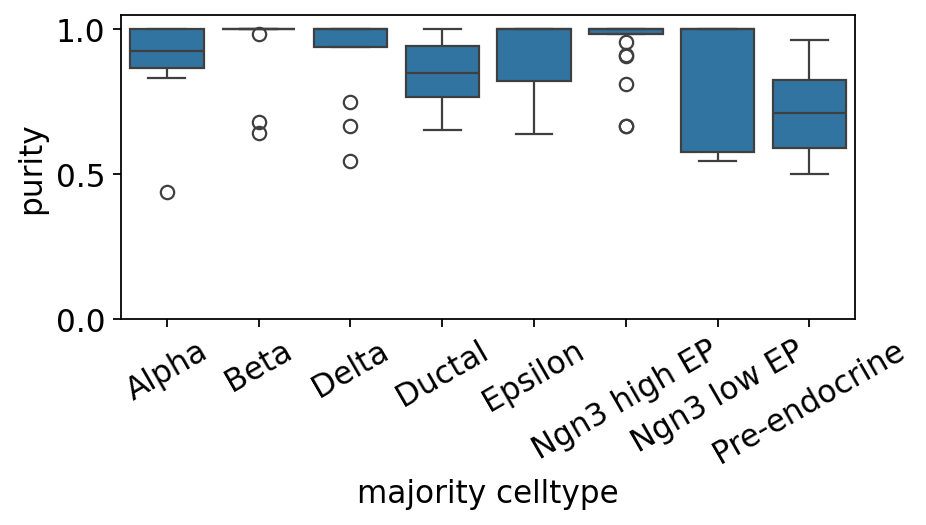

<Axes: xlabel='majority celltype', ylabel='purity'>

In [10]:
# Per-celltype boxplot of metacell purity.
ov.pl.metacell_purity_box(mc, label_key='clusters')

## 10. Metacell-level UMAP

A common downstream use of metacells is to treat them as a much smaller
"atlas" of pseudo-cells and re-run the standard omicverse preprocess → PCA
→ UMAP loop on them.  Cell-type signal should survive.

🔍 [2026-05-19 17:25:51] Running preprocessing in 'cpu' mode...
Begin robust gene identification
    After filtration, 2000/2000 genes are kept.
    Among 2000 genes, 2000 genes are robust.
✅ Robust gene identification completed successfully.
Begin size normalization: shiftlog and HVGs selection pearson

🔍 Count Normalization:
   Target sum: 500000.0
   Exclude highly expressed: True
   Max fraction threshold: 0.2
   ⚠️ Excluding 1 highly-expressed genes from normalization computation
   Excluded genes: ['Ghrl']

✅ Count Normalization Completed Successfully!
   ✓ Processed: 100 cells × 2,000 genes
   ✓ Runtime: 0.00s

🔍 Highly Variable Genes Selection (Experimental):
   Method: pearson_residuals
   Target genes: 2,000
   Theta (overdispersion): 100

✅ Experimental HVG Selection Completed Successfully!
   ✓ Selected: 2,000 highly variable genes out of 2,000 total (100.0%)
   ✓ Results added to AnnData object:
     • 'highly_variable': Boolean vector (adata.var)
     • 'highly_variable_ra

   🔧 PCA solver used: covariance_eigh
    finished✅ (0.96s)

╭─ SUMMARY: pca ─────────────────────────────────────────────────────╮
│  Duration: 0.9658s                                                 │
│  Shape:    100 x 2,000 (Unchanged)                                 │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● UNS    │ ✚ pca                                                  │
│           │ └─ params: {'zero_center': True, 'use_highly_variable': Tr...│
│           │ ✚ scaled|original|cum_sum_eigenvalues                  │
│           │ ✚ scaled|original|pca_var_ratios                       │
│                                                                    │
│  ● OBSM   │ ✚ X_pca (array, 100x30)                                │
│           │ ✚ scaled|original|X_pca (array, 100x30)                │
│         

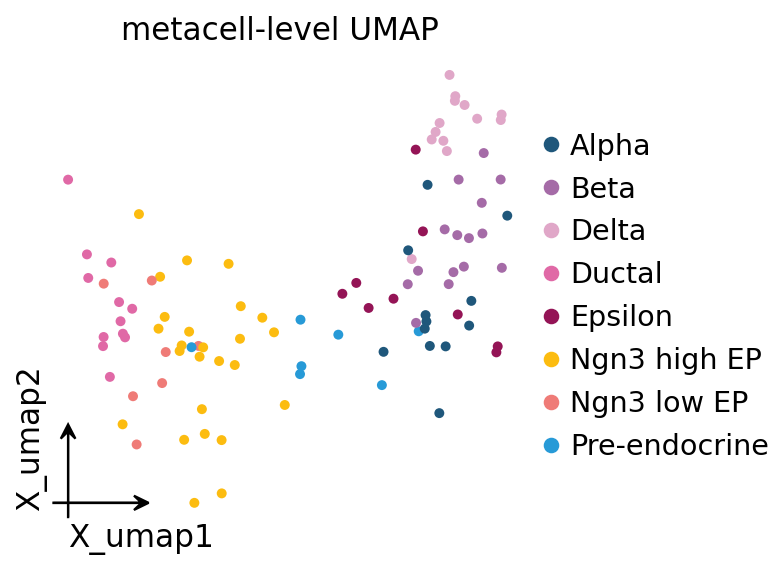

In [11]:
# Treat the metacell AnnData as a smaller dataset and run the standard
# omicverse preprocess -> pca -> neighbors -> umap loop on it.
ad_mc = ov.pp.preprocess(ad_mc, mode='shiftlog|pearson',
                          n_HVGs=min(2000, ad_mc.n_vars))
ad_mc = ad_mc[:, ad_mc.var.highly_variable_features]
ov.pp.scale(ad_mc)
ov.pp.pca(ad_mc, layer='scaled', n_pcs=min(30, ad_mc.n_obs - 1))
ad_mc.obsm['X_pca'] = ad_mc.obsm['scaled|original|X_pca']
ov.pp.neighbors(ad_mc, n_neighbors=min(15, ad_mc.n_obs - 1), use_rep='X_pca')
ov.pp.umap(ad_mc)
ov.pl.embedding(ad_mc, basis='X_umap', color='clusters',
                frameon='small', title='metacell-level UMAP', size=80)

## 11. Top markers per celltype on the metacell AnnData

In [12]:
# Find top markers per celltype on the metacell AnnData (omicverse helper —
# drops the categories with <2 metacells automatically and reports cell-type
# fractions ``pts`` along with the gene names).
counts = ad_mc.obs['clusters'].value_counts()
keep = counts[counts >= 2].index.tolist()
ad_mc_for_de = ad_mc[ad_mc.obs['clusters'].isin(keep)].copy()
ad_mc_for_de.obs['clusters'] = ad_mc_for_de.obs['clusters'].astype('category')

ov.single.find_markers(ad_mc_for_de, groupby='clusters', method='wilcoxon',
                       key_added='rank_genes_groups', pts=True, use_gpu=False)
ov.single.get_markers(ad_mc_for_de, n_genes=3, key='rank_genes_groups')

🔍 Finding marker genes | method: wilcoxon | groupby: clusters | n_groups: 8 | n_genes: 50
✅ Done | 8 groups × 50 genes | corr: benjamini-hochberg | stored in adata.uns['rank_genes_groups']


,group,rank,names,scores,logfoldchanges,pvals,pvals_adj,pct_group,pct_rest
0,Alpha,1,Zcchc18,5.483887,5.577512,4.160799e-08,7.539482e-05,1.0,0.727273
1,Alpha,2,Smarca1,5.377816,3.803625,7.539482e-08,7.539482e-05,1.0,0.818182
2,Alpha,3,Rai2,5.229316,4.840132,1.701382e-07,1.134255e-04,1.0,0.500000
3,Beta,1,Sytl4,6.153965,7.999855,7.556929e-10,2.206887e-07,1.0,0.258824
4,Beta,2,Ins2,6.134659,10.150820,8.534227e-10,2.206887e-07,1.0,0.517647
5,Beta,3,Ociad2,6.115352,4.848029,9.634404e-10,2.206887e-07,1.0,0.647059
6,Delta,1,Sst,5.796038,12.698734,6.789978e-09,6.518420e-06,1.0,0.551724
7,Delta,2,Hhex,5.796038,7.338409,6.789978e-09,6.518420e-06,1.0,0.655172
8,Delta,3,Rbp4,5.734542,6.061865,9.777630e-09,6.518420e-06,1.0,0.862069
9,Ductal,1,Hpgd,5.600566,7.645501,2.136534e-08,5.923214e-06,1.0,0.227273


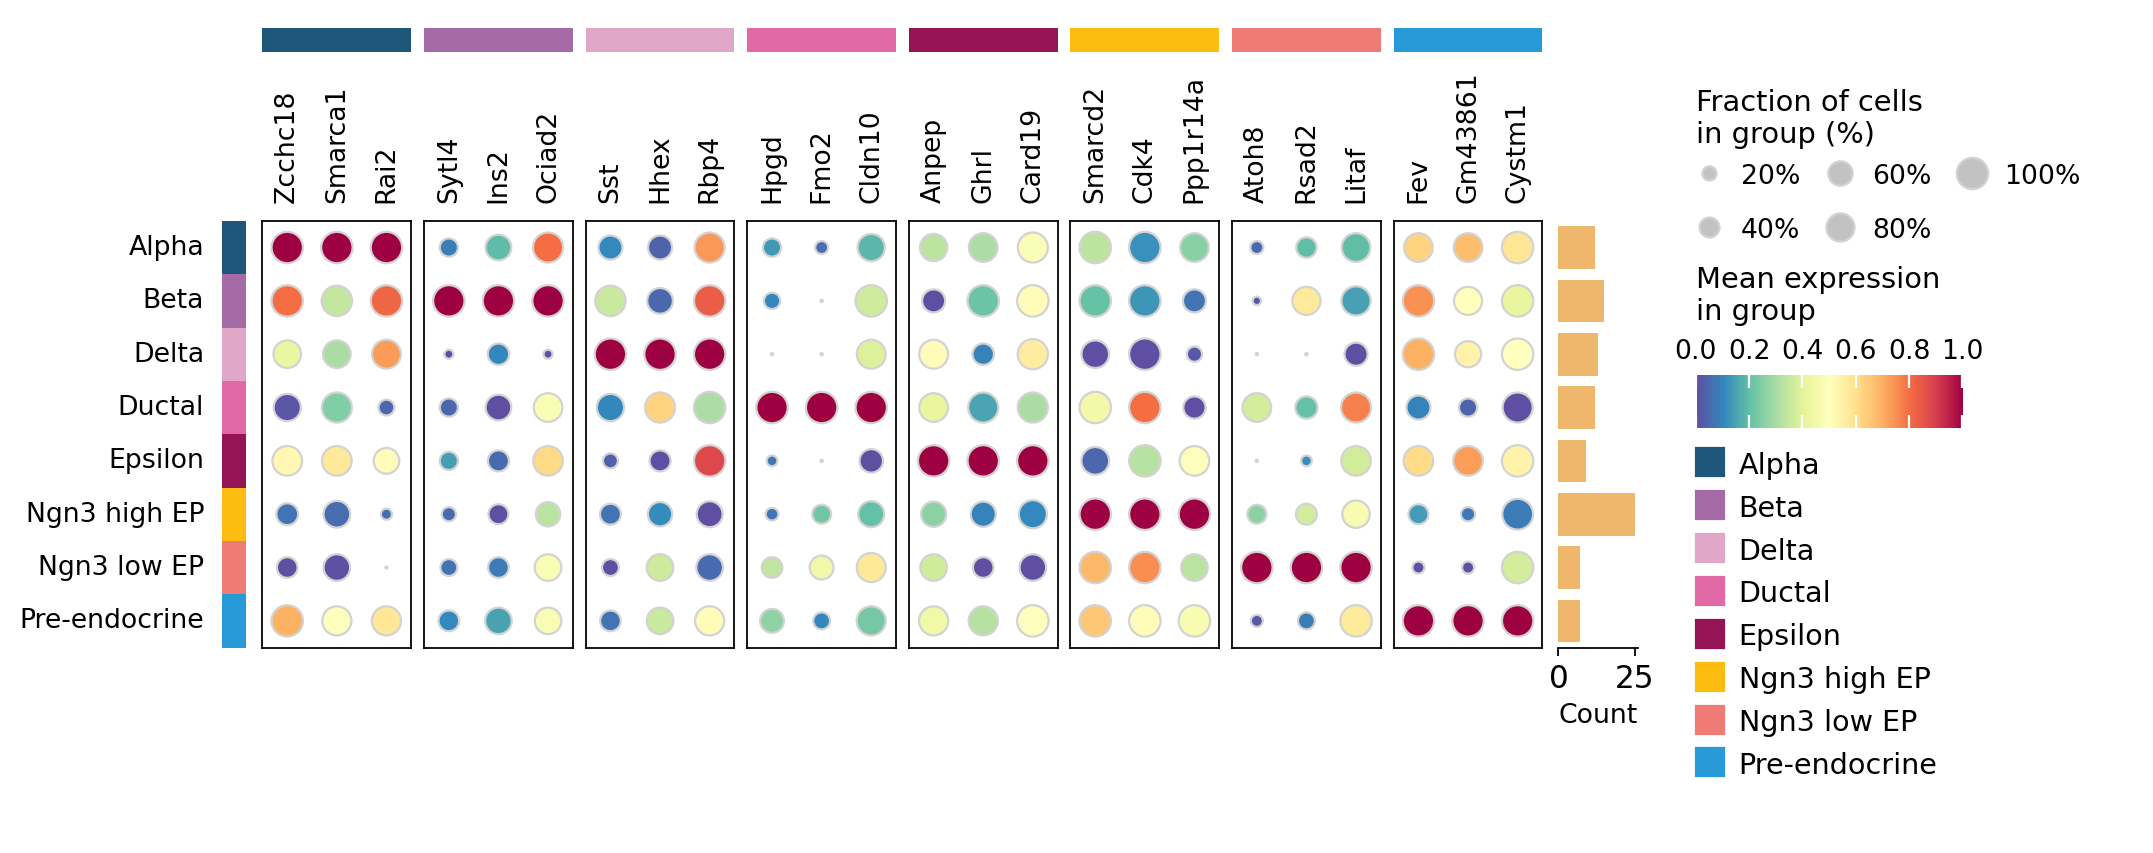

In [13]:
# Dotplot of top markers per metacell-level celltype.
ov.pl.markers_dotplot(ad_mc_for_de, groupby='clusters', n_genes=3,
                      key='rank_genes_groups')

## 12. GeoSketch exclusive: rare-population coverage

The point of GeoSketch is **even manifold coverage** — rare cell types should
be over-represented in the sketch compared to uniform random sampling.
Check this by counting how many of each celltype made it into the sketch.

In [14]:
# Compare sketch vs uniform random of the same size.
sketch_idx = mc._fit_result.backend_meta['sketch_idx']
sketch_labels  = adata.obs['clusters'].iloc[sketch_idx]
uniform_labels = adata.obs['clusters'].sample(n=len(sketch_idx), random_state=0)

counts = pd.DataFrame({
    'all_cells':      adata.obs['clusters'].value_counts(),
    'geosketch':      sketch_labels.value_counts(),
    'uniform_random': uniform_labels.value_counts(),
}).fillna(0).astype(int)
counts['geosketch_boost'] = (
    counts['geosketch'] / counts['all_cells']
    - counts['uniform_random'] / counts['all_cells']
)
counts.sort_values('all_cells')

,all_cells,geosketch,uniform_random,geosketch_boost
clusters,,,,
Delta,69,13,1,0.173913
Epsilon,138,11,2,0.065217
Ngn3 low EP,249,10,11,-0.004016
Alpha,470,13,8,0.010638
Beta,565,14,12,0.003540
Pre-endocrine,586,4,11,-0.011945
Ngn3 high EP,637,26,25,0.001570
Ductal,916,9,30,-0.022926


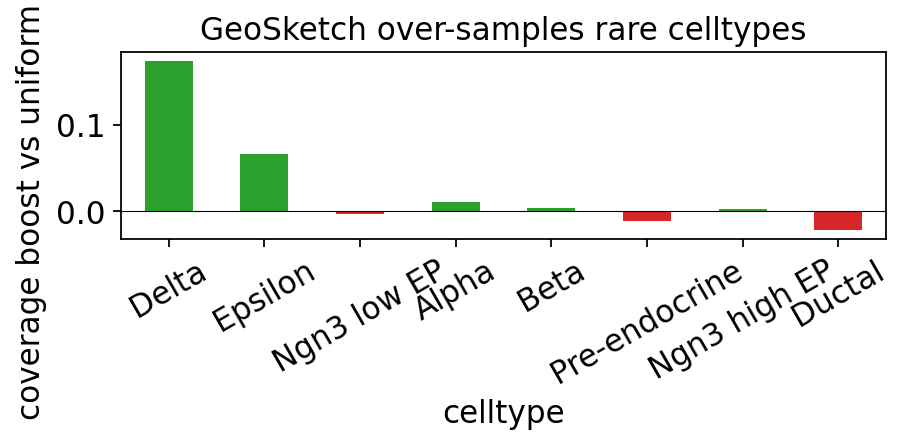

In [15]:
# Bar plot: GeoSketch's coverage boost per celltype.
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(6, 3))
ordered = counts.sort_values('all_cells')
ordered['geosketch_boost'].plot.bar(
    ax=ax, color=ordered['geosketch_boost']
        .apply(lambda x: '#2ca02c' if x > 0 else '#d62728'))
ax.axhline(0, color='black', linewidth=0.5)
ax.set_ylabel('coverage boost vs uniform random')
ax.set_xlabel('celltype'); ax.tick_params(axis='x', rotation=30)
ax.set_title('GeoSketch over-samples rare celltypes')
plt.tight_layout(); plt.show()

## 13. Save / load roundtrip

In [16]:
# Save/load roundtrip — every backend supports this.
import tempfile, os
with tempfile.NamedTemporaryFile(suffix='.pkl', delete=False) as f:
    path = f.name
mc.save(path)

mc2 = ov.single.MetaCell(adata.copy(), method='geosketch', n_metacells=100,
                          use_rep='X_pca', random_state=0)
mc2.load(path)
print(f'saved+loaded {path}')
os.remove(path)

saved+loaded /tmp/tmp_xe1z9_j.pkl


## 14. Takeaways

- GeoSketch is the right baseline for *visualisation / kNN* tasks: it gives
  you uniform coverage at ~20 lines of code.
- For *aggregation-sensitive* downstream tasks (DE, RNA velocity, GRN), the
  nearest-prototype partition omicverse builds on top is reasonable but
  inherits the same "one cell = one metacell prototype" limitation.  Prefer
  SEACells or MetaQ for these tasks.
- The rare-population boost in the bar plot above is the real selling point —
  if you have a 0.1 %-frequency cell type that uniform random would miss,
  GeoSketch finds it.